# Análisis Exploratorio de Datos (EDA) - Proyecto de Trabajo Final

## Objetivos del Análisis
Este notebook contiene un análisis exploratorio completo de todos los datasets disponibles en el proyecto, incluyendo:

1. **Datasets principales** (CSVs listos para Databricks)
2. **Datos temporales de Conectados** (Artículos, Ofertas, Comunicados)
3. **Datos corporativos**
4. **Identificación de relaciones entre datasets**
5. **Propuesta de modelo de datos**

In [1]:
# Importar librerías necesarias
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
from pathlib import Path
import os
from datetime import datetime

# Configuración de visualización
warnings.filterwarnings('ignore')
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")
%matplotlib inline

# Configuración de pandas para mostrar más filas/columnas
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 100)
pd.set_option('display.width', None)

print("✓ Librerías importadas correctamente")

✓ Librerías importadas correctamente


## 1. Funciones Auxiliares para el Análisis

In [2]:
def analizar_dataframe(df, nombre):
    """
    Realiza un análisis completo de un DataFrame
    """
    print(f"\n{'='*80}")
    print(f"ANÁLISIS DE: {nombre}")
    print(f"{'='*80}\n")
    
    # Información básica
    print(f"📊 Dimensiones: {df.shape[0]:,} filas × {df.shape[1]} columnas")
    print(f"💾 Tamaño en memoria: {df.memory_usage(deep=True).sum() / 1024**2:.2f} MB\n")
    
    # Tipos de datos
    print("📋 Tipos de Datos:")
    tipos = df.dtypes.value_counts()
    for tipo, cantidad in tipos.items():
        print(f"  - {tipo}: {cantidad} columnas")
    
    # Valores faltantes
    print("\n🔍 Valores Faltantes:")
    missing = df.isnull().sum()
    missing_pct = (missing / len(df)) * 100
    missing_df = pd.DataFrame({
        'Faltantes': missing,
        'Porcentaje': missing_pct
    }).sort_values('Porcentaje', ascending=False)
    
    missing_df = missing_df[missing_df['Faltantes'] > 0]
    if len(missing_df) > 0:
        print(missing_df.head(10))
    else:
        print("  ✓ No hay valores faltantes")
    
    # Columnas
    print(f"\n📝 Columnas ({df.shape[1]}):")
    for i, col in enumerate(df.columns, 1):
        print(f"  {i:2d}. {col} ({df[col].dtype})")
    
    # Primeras filas
    print("\n👀 Primeras 3 filas:")
    display(df.head(3))
    
    return missing_df


def estadisticas_numericas(df, nombre):
    """
    Muestra estadísticas descriptivas de columnas numéricas
    """
    numeric_cols = df.select_dtypes(include=[np.number]).columns
    
    if len(numeric_cols) > 0:
        print(f"\n📈 Estadísticas Numéricas - {nombre}:")
        display(df[numeric_cols].describe().T)
    else:
        print(f"\n⚠️ No hay columnas numéricas en {nombre}")


def estadisticas_categoricas(df, nombre, max_categorias=20):
    """
    Muestra estadísticas de columnas categóricas
    """
    cat_cols = df.select_dtypes(include=['object']).columns
    
    if len(cat_cols) > 0:
        print(f"\n📊 Estadísticas Categóricas - {nombre}:")
        for col in cat_cols[:10]:  # Primeras 10 columnas categóricas
            n_unique = df[col].nunique()
            print(f"\n  Columna: {col}")
            print(f"  Valores únicos: {n_unique:,}")
            
            if n_unique <= max_categorias:
                print(f"  Top 5 valores:")
                print(df[col].value_counts().head())


def identificar_fechas(df):
    """
    Identifica y sugiere columnas que podrían ser fechas
    """
    posibles_fechas = []
    for col in df.columns:
        if any(palabra in col.lower() for palabra in ['fecha', 'date', 'time', 'año', 'mes', 'dia']):
            posibles_fechas.append(col)
    
    if posibles_fechas:
        print("\n📅 Posibles columnas de fecha detectadas:")
        for col in posibles_fechas:
            print(f"  - {col}")
    
    return posibles_fechas


print("✓ Funciones auxiliares definidas")

✓ Funciones auxiliares definidas


## 2. Cargar y Analizar Datasets Principales (CSV)

In [3]:
# Definir rutas
BASE_PATH = Path(r"data/listos_para_cargar_databricks")

# Listar todos los archivos CSV
csv_files = sorted(BASE_PATH.glob("*.csv"))

print(f"📁 Se encontraron {len(csv_files)} archivos CSV:")
for i, file in enumerate(csv_files, 1):
    print(f"  {i:2d}. {file.name}")

📁 Se encontraron 23 archivos CSV:
   1. buglum_reakt_diccionario_comportmientos.csv
   2. buglum_reakt_metas_observables.csv
   3. conectados_ingresos.csv
   4. Data_Conocimiento_Integrada.csv
   5. fechas_call_center.csv
   6. freshdesk_tickets.csv
   7. gforms_cavs.csv
   8. human_demanda_umc.csv
   9. kpis_negocio.csv
  10. manual_categorizacion_certificacion_umc.csv
  11. manual_poblacion_segmentada.csv
  12. manual_unidades_de_negocio_actualizado.csv
  13. poblacion_objetivo.csv
  14. siuc_asistencias.csv
  15. ssff_callcenter.csv
  16. ssff_certificaciones.csv
  17. ssff_cursos.csv
  18. ssff_externalid.csv
  19. ssff_maestropersonas.csv
  20. ssff_reporte_resultados_masivo.csv
  21. ssff_reporte_resultados_retencion.csv
  22. ssff_reporte_resultados_soporte.csv
  23. ssff_reporte_resultados_whatsapp.csv


In [4]:
# Diccionario para almacenar todos los DataFrames
dataframes = {}
analisis_missing = {}

# Cargar todos los CSVs
print("Cargando archivos CSV...\n")

for csv_file in csv_files:
    try:
        nombre = csv_file.stem
        df = pd.read_csv(csv_file, encoding='utf-8', low_memory=False)
        dataframes[nombre] = df
        print(f"✓ {nombre}: {df.shape[0]:,} filas × {df.shape[1]} columnas")
    except Exception as e:
        print(f"✗ Error cargando {csv_file.name}: {e}")

print(f"\n✓ Total de datasets cargados: {len(dataframes)}")

Cargando archivos CSV...

✓ buglum_reakt_diccionario_comportmientos: 379 filas × 5 columnas
✓ buglum_reakt_metas_observables: 388 filas × 5 columnas
✓ conectados_ingresos: 1,047,387 filas × 3 columnas
✓ Data_Conocimiento_Integrada: 10,732 filas × 8 columnas
✓ fechas_call_center: 686 filas × 2 columnas
✓ freshdesk_tickets: 14,449 filas × 36 columnas
✓ gforms_cavs: 2,856 filas × 18 columnas
✓ human_demanda_umc: 238 filas × 35 columnas
✓ kpis_negocio: 87,652 filas × 8 columnas
✓ manual_categorizacion_certificacion_umc: 1,268 filas × 11 columnas
✓ manual_poblacion_segmentada: 11,293 filas × 13 columnas
✓ manual_unidades_de_negocio_actualizado: 1,087 filas × 7 columnas
✓ poblacion_objetivo: 2,199 filas × 8 columnas
✓ siuc_asistencias: 1,713,155 filas × 26 columnas
✓ ssff_callcenter: 5,601 filas × 13 columnas
✓ ssff_certificaciones: 28,465 filas × 46 columnas
✓ ssff_cursos: 5,172 filas × 13 columnas
✓ ssff_externalid: 824,115 filas × 13 columnas
✓ ssff_maestropersonas: 823,248 filas × 31 col

### 2.1 Análisis Individual de Cada Dataset

In [5]:
# Analizar cada dataset
for nombre, df in dataframes.items():
    missing_info = analizar_dataframe(df, nombre)
    analisis_missing[nombre] = missing_info
    estadisticas_numericas(df, nombre)
    estadisticas_categoricas(df, nombre)
    identificar_fechas(df)


ANÁLISIS DE: buglum_reakt_diccionario_comportmientos

📊 Dimensiones: 379 filas × 5 columnas
💾 Tamaño en memoria: 0.18 MB

📋 Tipos de Datos:
  - object: 5 columnas

🔍 Valores Faltantes:
                 Faltantes  Porcentaje
Nueva_Habilidad        109   28.759894
Rol                     84   22.163588
Id_Observable           42   11.081794
Perfil                  42   11.081794

📝 Columnas (5):
   1. Observable (object)
   2. Id_Observable (object)
   3. Nueva_Habilidad (object)
   4. Perfil (object)
   5. Rol (object)

👀 Primeras 3 filas:


,Observable,Id_Observable,Nueva_Habilidad,Perfil,Rol
0,Gestiona adecuadamente situaciones de alta pre...,OBS_00001,GESTIÓN DE EMOCIONES,CONOCIMIENTOS (CONSULTOR EMPRESAS Y NEGOCIOS (...,CONSULTOR
1,Identifica patrones de mejora o áreas de mejor...,OBS_00002,HABILIDADES DIGITALES,CONOCIMIENTOS (ASESOR VENTA UNIDAD MERCADO MAS...,ASESOR
2,A partir del conocimiento del sector y/o el cl...,OBS_00003,HABILIDAD COMERCIAL,CONOCIMIENTOS (CONSULTOR EMPRESAS Y NEGOCIOS (...,CONSULTOR



⚠️ No hay columnas numéricas en buglum_reakt_diccionario_comportmientos

📊 Estadísticas Categóricas - buglum_reakt_diccionario_comportmientos:

  Columna: Observable
  Valores únicos: 367

  Columna: Id_Observable
  Valores únicos: 266

  Columna: Nueva_Habilidad
  Valores únicos: 18
  Top 5 valores:
Nueva_Habilidad
HABILIDAD COMERCIAL       58
HABILIDADES DIGITALES     43
GESTIÓN Y ORGANIZACIÓN    31
GESTIÓN DE EMOCIONES      28
SERVICIO AL CLIENTE       21
Name: count, dtype: int64

  Columna: Perfil
  Valores únicos: 17
  Top 5 valores:
Perfil
CONOCIMIENTOS (CONSULTOR EMPRESAS Y NEGOCIOS (EMPRESAS, NEGOCIOS))     49
CONOCIMIENTOS (ASESOR VENTA UNIDAD MERCADO MASIVO (TMK,COMERCIAL))     49
CONOCIMIENTOS (ASESOR VENTA Y SERVICIO UNIDAD MERCADO MASIVO (CAV))    42
CONOCIMIENTOS (ESPECIALISTA COMERCIAL)                                 27
ASESOR                                                                 26
Name: count, dtype: int64

  Columna: Rol
  Valores únicos: 4
  Top 5 valore

,Canal,Region,Meta,Llave,Fecha
0,CALL CENTER,R1,85,CALL CENTER-R1-202507,202507
1,CALL CENTER,R2,102,CALL CENTER-R2-202507,202507
2,CALL CENTER,R3,31,CALL CENTER-R3-202507,202507



📈 Estadísticas Numéricas - buglum_reakt_metas_observables:


...


📊 Estadísticas Categóricas - ssff_reporte_resultados_soporte:

  Columna: Nombre
  Valores únicos: 222

  Columna: Correo
  Valores únicos: 222

  Columna: Pregunta
  Valores únicos: 10
  Top 5 valores:
Pregunta
Laura, cliente de Claro, desea mejorar su plan de hogar, ya que al momento de jugar presenta lentitud en el servicio y siente. Actualmente, no tiene claro cuántos MB exactos de descarga tiene y se comunica con la línea de servicio al cliente para verificar esta información y conocer cuál es la mejor opción para ella. Ha visto en internet dos planes que le podrían interesar: uno de menor valor que incluye 350 MB y Ultra Wifi, y otro de mayor valor que incluye 500 MB, y Ultra Wifi. Actualmente Laura busca una alternativa que se ajuste a su presupuesto y le genere mejores beneficios que los que cuenta actualmente. ¿Qué pasos seguirías para gestionar la situación de Laura y asesorarla adecuadamente?                                                                                   

,Nombre,Correo,Cédula,Pregunta,Respuesta,Habilidad,Valor,Indicador
0,Alejandra Alarcón Ossa,alejandra.alarcon@op.brm.co,1000220361,"Laura, cliente de Claro, desea mejorar su plan...",Para brindarle un excelente servicio a Laura s...,Cambios en el servicio,50,NPS-FCR
1,Alejandra Alarcón Ossa,alejandra.alarcon@op.brm.co,1000220361,"Angélica, una cliente del servicio móvil postp...","Angélica, entiendo lo frustrante que ha sido e...",Cierre de la atención inicial,100,NPS-FCR
2,Alejandra Alarcón Ossa,alejandra.alarcon@op.brm.co,1000220361,Camila es una usuaria del servicio de Claro Ho...,"Espero que estés bien, señora Camila. Entiendo...",Escalamiento a segundo nivel.,100,NPS-FCR



📈 Estadísticas Numéricas - ssff_reporte_resultados_whatsapp:


,count,mean,std,min,25%,50%,75%,max
Cédula,750.0,1.005696e+09,2.077817e+08,1392039.0,1.004049e+09,1.025141e+09,1.048271e+09,1.234095e+09
Valor,750.0,6.796000e+01,3.961478e+01,5.0,5.000000e+01,1.000000e+02,1.000000e+02,1.000000e+02



📊 Estadísticas Categóricas - ssff_reporte_resultados_whatsapp:

  Columna: Nombre
  Valores únicos: 75

  Columna: Correo
  Valores únicos: 75

  Columna: Pregunta
  Valores únicos: 10
  Top 5 valores:
Pregunta
Laura, cliente de Claro, desea mejorar su plan postpago ya que no le suelen alcanzar sus GB mensuales. Actualmente, no tiene claro cuántos GB exactos tiene y se comunica a través del chat de Whatsapp para verificar esta información y conocer cuál es la mejor opción para ella. Ha visto en internet dos planes que le podrían interesar: uno de menor valor que incluye 85GB y minutos ilimitados, y otro de mayor valor que incluye 110GB, minutos ilimitados, MAX y asistencia. Actualmente Laura busca una alternativa que se ajuste a su presupuesto y le genere mejores beneficios que los que cuenta actualmente. ¿Qué pasos seguirías para gestionar la situación de Laura y asesorarla adecuadamente?                                                                                                 

## 3. Resumen General de Todos los Datasets

In [6]:
# Crear resumen general
resumen_data = []

for nombre, df in dataframes.items():
    resumen_data.append({
        'Dataset': nombre,
        'Filas': df.shape[0],
        'Columnas': df.shape[1],
        'Tamaño_MB': df.memory_usage(deep=True).sum() / 1024**2,
        'Columnas_Numericas': len(df.select_dtypes(include=[np.number]).columns),
        'Columnas_Texto': len(df.select_dtypes(include=['object']).columns),
        'Total_Nulos': df.isnull().sum().sum(),
        'Pct_Nulos': (df.isnull().sum().sum() / (df.shape[0] * df.shape[1])) * 100
    })

df_resumen = pd.DataFrame(resumen_data).sort_values('Filas', ascending=False)

print("\n📊 RESUMEN GENERAL DE TODOS LOS DATASETS")
print("="*100)
display(df_resumen)

print(f"\n📈 Estadísticas Agregadas:")
print(f"  Total de filas en todos los datasets: {df_resumen['Filas'].sum():,}")
print(f"  Total de columnas (suma): {df_resumen['Columnas'].sum():,}")
print(f"  Tamaño total en memoria: {df_resumen['Tamaño_MB'].sum():.2f} MB")
print(f"  Promedio de valores nulos: {df_resumen['Pct_Nulos'].mean():.2f}%")


📊 RESUMEN GENERAL DE TODOS LOS DATASETS


,Dataset,Filas,Columnas,Tamaño_MB,Columnas_Numericas,Columnas_Texto,Total_Nulos,Pct_Nulos
13,siuc_asistencias,1713155,26,2559.189227,5,21,13346,0.029963
2,conectados_ingresos,1047387,3,172.222897,0,3,616,0.019604
17,ssff_externalid,824115,13,569.589016,1,12,2134960,19.927764
18,ssff_maestropersonas,823248,31,1407.204689,0,31,6156996,24.125509
8,kpis_negocio,87652,8,29.587502,2,6,0,0.000000
15,ssff_certificaciones,28465,46,47.868335,26,20,209472,15.997678
5,freshdesk_tickets,14449,36,25.797459,7,29,132769,25.524450
10,manual_poblacion_segmentada,11293,13,6.410222,4,9,3324,2.264166
3,Data_Conocimiento_Integrada,10732,8,3.153484,4,4,18404,21.435893
14,ssff_callcenter,5601,13,30.290390,3,10,0,0.000000



📈 Estadísticas Agregadas:
  Total de filas en todos los datasets: 4,589,060
  Total de columnas (suma): 333
  Tamaño total en memoria: 4897.79 MB
  Promedio de valores nulos: 8.54%


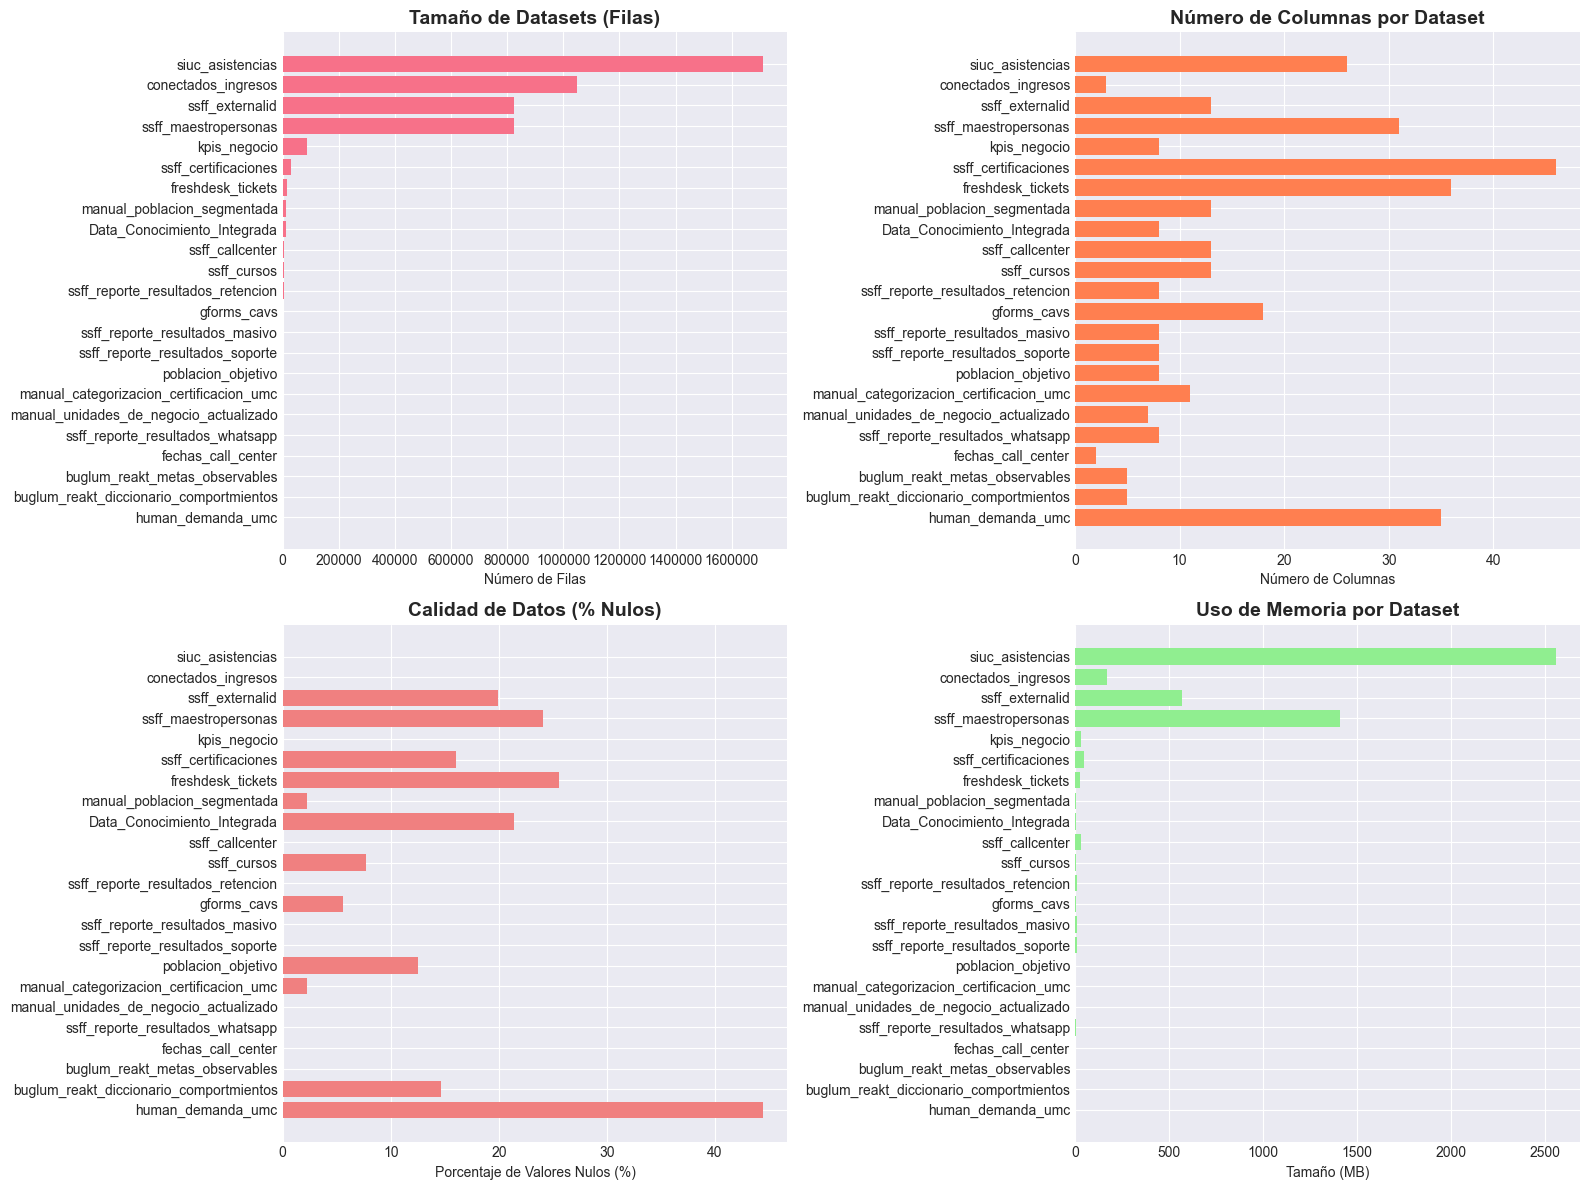

In [7]:
# Visualización del resumen
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# Gráfico 1: Número de filas por dataset
df_resumen_plot = df_resumen.sort_values('Filas', ascending=True)
axes[0, 0].barh(df_resumen_plot['Dataset'], df_resumen_plot['Filas'])
axes[0, 0].set_xlabel('Número de Filas')
axes[0, 0].set_title('Tamaño de Datasets (Filas)', fontsize=14, fontweight='bold')
axes[0, 0].ticklabel_format(style='plain', axis='x')

# Gráfico 2: Número de columnas por dataset
axes[0, 1].barh(df_resumen_plot['Dataset'], df_resumen_plot['Columnas'], color='coral')
axes[0, 1].set_xlabel('Número de Columnas')
axes[0, 1].set_title('Número de Columnas por Dataset', fontsize=14, fontweight='bold')

# Gráfico 3: Porcentaje de valores nulos
axes[1, 0].barh(df_resumen_plot['Dataset'], df_resumen_plot['Pct_Nulos'], color='lightcoral')
axes[1, 0].set_xlabel('Porcentaje de Valores Nulos (%)')
axes[1, 0].set_title('Calidad de Datos (% Nulos)', fontsize=14, fontweight='bold')

# Gráfico 4: Tamaño en memoria
axes[1, 1].barh(df_resumen_plot['Dataset'], df_resumen_plot['Tamaño_MB'], color='lightgreen')
axes[1, 1].set_xlabel('Tamaño (MB)')
axes[1, 1].set_title('Uso de Memoria por Dataset', fontsize=14, fontweight='bold')

plt.tight_layout()
plt.show()

## 4. Análisis de Datasets Específicos Importantes

### 4.1 SSFF - Maestro de Personas

In [8]:
# Análisis específico del maestro de personas
if 'ssff_maestropersonas' in dataframes:
    df_personas = dataframes['ssff_maestropersonas']
    
    print("\n🧑 ANÁLISIS ESPECÍFICO: Maestro de Personas")
    print("="*80)
    
    # Identificar columna ID
    posibles_ids = [col for col in df_personas.columns if 'id' in col.lower()]
    print(f"\nPosibles columnas ID: {posibles_ids}")
    
    # Análisis de duplicados
    if posibles_ids:
        for id_col in posibles_ids[:3]:
            duplicados = df_personas[id_col].duplicated().sum()
            print(f"  Duplicados en {id_col}: {duplicados:,}")
else:
    print("⚠️ Dataset 'ssff_maestropersonas' no encontrado")


🧑 ANÁLISIS ESPECÍFICO: Maestro de Personas

Posibles columnas ID: ['ID de sistema de usuario', 'Apellidos', 'SubDistribuidor', 'Colombia Cédula de ciudadanía  DOCUMENTO DE IDENTIFICACION']
  Duplicados en ID de sistema de usuario: 704
  Duplicados en Apellidos: 541,310
  Duplicados en SubDistribuidor: 823,243


### 4.2 Análisis de Cursos y Certificaciones

In [9]:
# Análisis de cursos
if 'ssff_cursos' in dataframes:
    df_cursos = dataframes['ssff_cursos']
    
    print("\n📚 ANÁLISIS ESPECÍFICO: Cursos")
    print("="*80)
    
    # Estadísticas básicas
    print(f"Total de registros de cursos: {len(df_cursos):,}")
    
    # Buscar columnas de cursos
    posibles_curso_cols = [col for col in df_cursos.columns if any(x in col.lower() for x in ['curso', 'course', 'nombre'])]
    print(f"\nColumnas relacionadas con cursos: {posibles_curso_cols}")
    
    if posibles_curso_cols:
        print(f"\nTop 10 cursos más frecuentes:")
        print(df_cursos[posibles_curso_cols[0]].value_counts().head(10))

# Análisis de certificaciones
if 'ssff_certificaciones' in dataframes:
    df_cert = dataframes['ssff_certificaciones']
    
    print("\n🎓 ANÁLISIS ESPECÍFICO: Certificaciones")
    print("="*80)
    print(f"Total de certificaciones: {len(df_cert):,}")


📚 ANÁLISIS ESPECÍFICO: Cursos
Total de registros de cursos: 5,172

Columnas relacionadas con cursos: ['Nombre', 'Segundo nombre']

Top 10 cursos más frecuentes:
Nombre
SUANNY DAYANNA    829
Juan David         22
LUISA FERNANDA     19
VALENTINA          18
MARIA FERNANDA     17
SANTIAGO           17
JUAN CAMILO        17
Luisa Fernanda     16
Santiago           16
DANIELA            16
Name: count, dtype: int64

🎓 ANÁLISIS ESPECÍFICO: Certificaciones
Total de certificaciones: 28,465


### 4.3 Análisis de Tickets Freshdesk

In [10]:
if 'freshdesk_tickets' in dataframes:
    df_tickets = dataframes['freshdesk_tickets']
    
    print("\n🎫 ANÁLISIS ESPECÍFICO: Tickets Freshdesk")
    print("="*80)
    
    # Buscar columnas de estado
    posibles_estado = [col for col in df_tickets.columns if 'estado' in col.lower() or 'status' in col.lower()]
    if posibles_estado:
        print(f"\nDistribución de estados:")
        print(df_tickets[posibles_estado[0]].value_counts())
    
    # Buscar columnas de prioridad
    posibles_prioridad = [col for col in df_tickets.columns if 'prioridad' in col.lower() or 'priority' in col.lower()]
    if posibles_prioridad:
        print(f"\nDistribución de prioridades:")
        print(df_tickets[posibles_prioridad[0]].value_counts())


🎫 ANÁLISIS ESPECÍFICO: Tickets Freshdesk

Distribución de estados:
Estado
Resolved    9797
Closed      4610
Open          34
Pending        8
Name: count, dtype: int64

Distribución de prioridades:
Prioridad
Low       8452
Medium    4399
High      1111
Urgent     487
Name: count, dtype: int64


## 5. Análisis de Datos Temporales (Conectados)

In [11]:
# Análisis de archivos temporales de Conectados
CONECTADOS_PATH = Path(r"data/sinformato/Conectados")

# Artículos
articulos_files = sorted((CONECTADOS_PATH / "Articulos").glob("*.xlsx"))
ofertas_files = sorted((CONECTADOS_PATH / "Base Oferta").glob("*.xlsx"))
comunicados_files = sorted((CONECTADOS_PATH / "Comunicados").glob("*.xlsx"))

print(f"📁 Archivos temporales encontrados:")
print(f"  - Artículos: {len(articulos_files)} archivos")
print(f"  - Ofertas: {len(ofertas_files)} archivos")
print(f"  - Comunicados: {len(comunicados_files)} archivos")

📁 Archivos temporales encontrados:
  - Artículos: 25 archivos
  - Ofertas: 22 archivos
  - Comunicados: 22 archivos


In [12]:
# Analizar estructura de archivos temporales (muestra)
def analizar_archivo_temporal(file_path):
    """Analiza un archivo temporal de Excel"""
    try:
        df = pd.read_excel(file_path)
        fecha_str = file_path.stem.split()[0]  # Extrae la fecha del nombre
        return {
            'fecha': fecha_str,
            'filas': len(df),
            'columnas': len(df.columns),
            'cols_list': list(df.columns)
        }
    except Exception as e:
        return {'fecha': file_path.stem, 'error': str(e)}

# Analizar muestra de artículos
if len(articulos_files) > 0:
    print("\n📊 Análisis de Artículos (Muestra):")
    print("="*80)
    
    # Analizar primero y último archivo
    for archivo in [articulos_files[0], articulos_files[-1]]:
        info = analizar_archivo_temporal(archivo)
        if 'error' not in info:
            print(f"\nArchivo: {archivo.name}")
            print(f"  Filas: {info['filas']:,}")
            print(f"  Columnas: {info['columnas']}")
            print(f"  Columnas: {', '.join(info['cols_list'][:5])}...")


📊 Análisis de Artículos (Muestra):

Archivo: 01.04.2025 articulos.xlsx
  Filas: 41,220
  Columnas: 5
  Columnas: id, cedula, web, url, fecha_hora...

Archivo: 29.09.2025 articulos.xlsx
  Filas: 322,682
  Columnas: 5
  Columnas: id, cedula, web, url, fecha_hora...



📈 Tendencia Temporal de Artículos


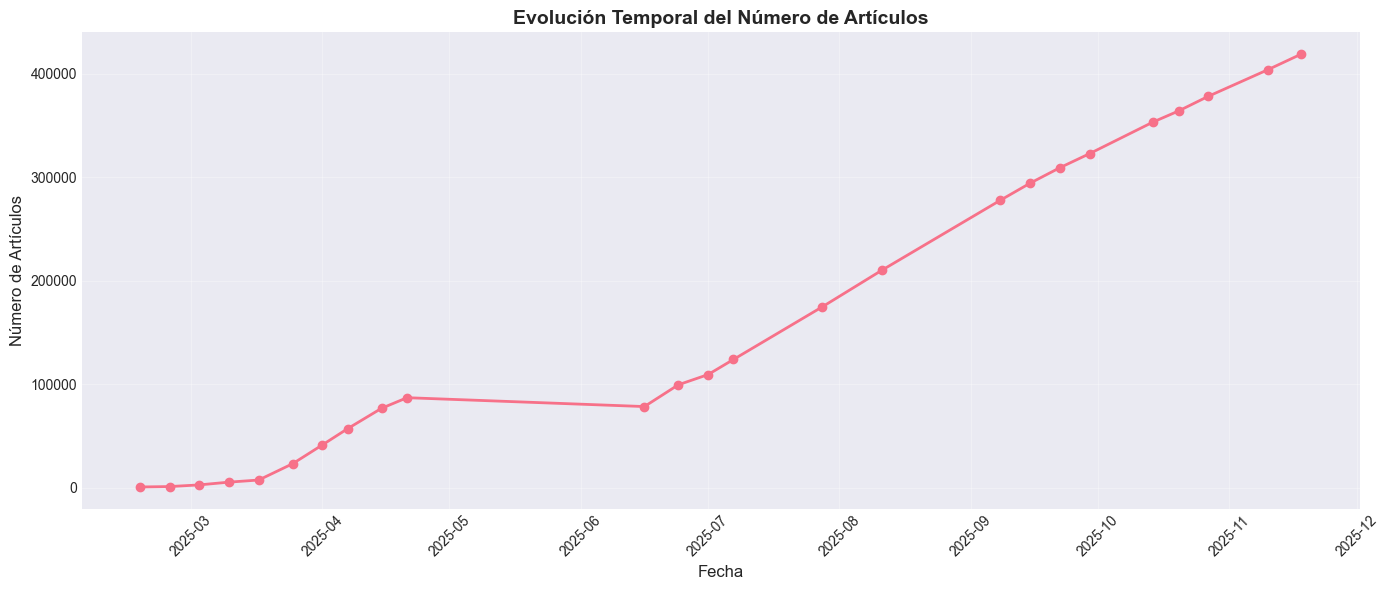


Estadísticas de la serie temporal:
  Promedio de artículos: 168,766
  Mínimo: 642
  Máximo: 419,002
  Desviación estándar: 148,177


In [13]:
# Tendencia temporal de artículos
if len(articulos_files) > 0:
    print("\n📈 Tendencia Temporal de Artículos")
    
    tendencia_articulos = []
    for archivo in articulos_files:
        info = analizar_archivo_temporal(archivo)
        if 'error' not in info:
            tendencia_articulos.append(info)
    
    df_tendencia = pd.DataFrame(tendencia_articulos)
    
    # Convertir fecha a datetime
    try:
        df_tendencia['fecha_dt'] = pd.to_datetime(df_tendencia['fecha'], format='%d.%m.%Y')
        df_tendencia = df_tendencia.sort_values('fecha_dt')
        
        # Gráfico de tendencia
        fig, ax = plt.subplots(figsize=(14, 6))
        ax.plot(df_tendencia['fecha_dt'], df_tendencia['filas'], marker='o', linewidth=2, markersize=6)
        ax.set_xlabel('Fecha', fontsize=12)
        ax.set_ylabel('Número de Artículos', fontsize=12)
        ax.set_title('Evolución Temporal del Número de Artículos', fontsize=14, fontweight='bold')
        ax.grid(True, alpha=0.3)
        plt.xticks(rotation=45)
        plt.tight_layout()
        plt.show()
        
        print(f"\nEstadísticas de la serie temporal:")
        print(f"  Promedio de artículos: {df_tendencia['filas'].mean():,.0f}")
        print(f"  Mínimo: {df_tendencia['filas'].min():,}")
        print(f"  Máximo: {df_tendencia['filas'].max():,}")
        print(f"  Desviación estándar: {df_tendencia['filas'].std():,.0f}")
    except Exception as e:
        print(f"Error procesando fechas: {e}")

## 6. Identificación de Relaciones Entre Datasets

In [14]:
# Buscar columnas comunes entre datasets
print("🔗 IDENTIFICACIÓN DE POSIBLES RELACIONES ENTRE DATASETS")
print("="*100)

# Extraer columnas de cada dataset
datasets_cols = {nombre: set(df.columns) for nombre, df in dataframes.items()}

# Buscar columnas comunes
relaciones_potenciales = []

nombres_datasets = list(dataframes.keys())
for i in range(len(nombres_datasets)):
    for j in range(i+1, len(nombres_datasets)):
        ds1 = nombres_datasets[i]
        ds2 = nombres_datasets[j]
        
        cols_comunes = datasets_cols[ds1] & datasets_cols[ds2]
        
        if cols_comunes:
            relaciones_potenciales.append({
                'Dataset_1': ds1,
                'Dataset_2': ds2,
                'Columnas_Comunes': ', '.join(sorted(cols_comunes)[:5]),  # Primeras 5
                'Total_Comunes': len(cols_comunes)
            })

df_relaciones = pd.DataFrame(relaciones_potenciales).sort_values('Total_Comunes', ascending=False)

if len(df_relaciones) > 0:
    print(f"\nSe encontraron {len(df_relaciones)} pares de datasets con columnas comunes:\n")
    display(df_relaciones.head(20))
else:
    print("\nNo se encontraron columnas comunes entre datasets")

🔗 IDENTIFICACIÓN DE POSIBLES RELACIONES ENTRE DATASETS

Se encontraron 87 pares de datasets con columnas comunes:



,Dataset_1,Dataset_2,Columnas_Comunes,Total_Comunes
85,ssff_reporte_resultados_retencion,ssff_reporte_resultados_whatsapp,"Correo, Cédula, Habilidad, Indicador, Nombre",8
82,ssff_reporte_resultados_masivo,ssff_reporte_resultados_soporte,"Correo, Cédula, Habilidad, Indicador, Nombre",8
81,ssff_reporte_resultados_masivo,ssff_reporte_resultados_retencion,"Correo, Cédula, Habilidad, Indicador, Nombre",8
84,ssff_reporte_resultados_retencion,ssff_reporte_resultados_soporte,"Correo, Cédula, Habilidad, Indicador, Nombre",8
86,ssff_reporte_resultados_soporte,ssff_reporte_resultados_whatsapp,"Correo, Cédula, Habilidad, Indicador, Nombre",8
72,ssff_externalid,ssff_maestropersonas,"Apellidos, Canal, Cédula, Empresa, ID de siste...",8
83,ssff_reporte_resultados_masivo,ssff_reporte_resultados_whatsapp,"Correo, Cédula, Habilidad, Indicador, Nombre",8
61,ssff_callcenter,ssff_reporte_resultados_masivo,"Correo, Indicador, Nombre, Pregunta, Respuesta",6
64,ssff_callcenter,ssff_reporte_resultados_whatsapp,"Correo, Indicador, Nombre, Pregunta, Respuesta",6
63,ssff_callcenter,ssff_reporte_resultados_soporte,"Correo, Indicador, Nombre, Pregunta, Respuesta",6


In [15]:
# Buscar columnas tipo ID en todos los datasets
print("\n🔑 IDENTIFICACIÓN DE CLAVES PRIMARIAS/FORÁNEAS")
print("="*100)

claves_por_dataset = {}

for nombre, df in dataframes.items():
    # Buscar columnas que contengan 'id', 'codigo', 'key'
    posibles_claves = [col for col in df.columns if any(x in col.lower() for x in ['id', 'codigo', 'key', 'clave'])]
    
    if posibles_claves:
        claves_info = []
        for col in posibles_claves:
            n_unique = df[col].nunique()
            n_total = len(df)
            pct_unique = (n_unique / n_total) * 100 if n_total > 0 else 0
            
            claves_info.append({
                'Columna': col,
                'Valores_Unicos': n_unique,
                'Total_Registros': n_total,
                'Pct_Unicidad': pct_unique,
                'Es_Clave_Primaria': pct_unique == 100
            })
        
        claves_por_dataset[nombre] = pd.DataFrame(claves_info)

# Mostrar claves por dataset
for nombre, df_claves in claves_por_dataset.items():
    print(f"\n📊 {nombre}:")
    display(df_claves)


🔑 IDENTIFICACIÓN DE CLAVES PRIMARIAS/FORÁNEAS

📊 buglum_reakt_diccionario_comportmientos:


,Columna,Valores_Unicos,Total_Registros,Pct_Unicidad,Es_Clave_Primaria
0,Id_Observable,266,379,70.184697,False
1,Nueva_Habilidad,18,379,4.749340,False



📊 Data_Conocimiento_Integrada:


,Columna,Valores_Unicos,Total_Registros,Pct_Unicidad,Es_Clave_Primaria
0,Habilidad,8,10732,0.074543,False



📊 fechas_call_center:


...

,Columna,Valores_Unicos,Total_Registros,Pct_Unicidad,Es_Clave_Primaria
0,Habilidad,10,3320,0.301205,False



📊 ssff_reporte_resultados_soporte:


,Columna,Valores_Unicos,Total_Registros,Pct_Unicidad,Es_Clave_Primaria
0,Habilidad,9,2230,0.403587,False



📊 ssff_reporte_resultados_whatsapp:


,Columna,Valores_Unicos,Total_Registros,Pct_Unicidad,Es_Clave_Primaria
0,Habilidad,9,750,1.2,False


## 7. Propuesta de Modelo de Datos

In [16]:
print("\n🏗️ PROPUESTA DE MODELO DE DATOS")
print("="*100)

print("""
Basado en el análisis exploratorio, se sugiere el siguiente modelo de datos:

### TABLAS MAESTRAS (Dimensiones)
1. **dim_personas** (maestropersonas)
   - Clave primaria: ID de persona
   - Atributos: datos demográficos, información laboral

2. **dim_cursos** (cursos)
   - Clave primaria: ID de curso
   - Atributos: nombre, descripción, tipo

3. **dim_tiempo**
   - Clave primaria: fecha
   - Atributos: año, mes, día, trimestre, semana

4. **dim_unidades_negocio** (manual_unidades_de_negocio_actualizado)
   - Clave primaria: ID unidad
   - Atributos: nombre, tipo, jerarquía

### TABLAS DE HECHOS (Facts)
1. **fact_certificaciones** (ssff_certificaciones)
   - Claves foráneas: ID persona, ID certificación, fecha
   - Métricas: estado, resultado, puntuación

2. **fact_tickets** (freshdesk_tickets)
   - Claves foráneas: ID ticket, ID persona, fecha
   - Métricas: tiempo de resolución, estado, prioridad

3. **fact_asistencias** (siuc_asistencias)
   - Claves foráneas: ID persona, ID curso, fecha
   - Métricas: asistencia, participación

4. **fact_ingresos** (conectados_ingresos)
   - Claves foráneas: fecha, ID unidad
   - Métricas: monto, tipo de ingreso

5. **fact_kpis** (kpis_negocio)
   - Claves foráneas: fecha, ID unidad
   - Métricas: valores de KPIs

### TABLAS DE REFERENCIA
- poblacion_objetivo
- manual_categorizacion_certificacion_umc
- manual_poblacion_segmentada
- buglum_reakt_diccionario_comportmientos

### DATOS TEMPORALES (Stage/Landing)
- Artículos, Ofertas, Comunicados (Conectados)
  → Consolidar en tablas únicas con dimensión temporal
""")


🏗️ PROPUESTA DE MODELO DE DATOS

Basado en el análisis exploratorio, se sugiere el siguiente modelo de datos:

### TABLAS MAESTRAS (Dimensiones)
1. **dim_personas** (maestropersonas)
   - Clave primaria: ID de persona
   - Atributos: datos demográficos, información laboral

2. **dim_cursos** (cursos)
   - Clave primaria: ID de curso
   - Atributos: nombre, descripción, tipo

3. **dim_tiempo**
   - Clave primaria: fecha
   - Atributos: año, mes, día, trimestre, semana

4. **dim_unidades_negocio** (manual_unidades_de_negocio_actualizado)
   - Clave primaria: ID unidad
   - Atributos: nombre, tipo, jerarquía

### TABLAS DE HECHOS (Facts)
1. **fact_certificaciones** (ssff_certificaciones)
   - Claves foráneas: ID persona, ID certificación, fecha
   - Métricas: estado, resultado, puntuación

2. **fact_tickets** (freshdesk_tickets)
   - Claves foráneas: ID ticket, ID persona, fecha
   - Métricas: tiempo de resolución, estado, prioridad

3. **fact_asistencias** (siuc_asistencias)
   - Claves

## 8. Calidad de Datos y Recomendaciones

In [17]:
print("\n✅ RECOMENDACIONES DE CALIDAD DE DATOS")
print("="*100)

# Analizar calidad general
problemas_calidad = []

for nombre, df in dataframes.items():
    # Porcentaje de nulos
    pct_nulos = (df.isnull().sum().sum() / (df.shape[0] * df.shape[1])) * 100
    
    if pct_nulos > 20:
        problemas_calidad.append({
            'Dataset': nombre,
            'Problema': 'Alto porcentaje de valores nulos',
            'Severidad': 'Alta',
            'Valor': f"{pct_nulos:.1f}%"
        })
    elif pct_nulos > 10:
        problemas_calidad.append({
            'Dataset': nombre,
            'Problema': 'Valores nulos moderados',
            'Severidad': 'Media',
            'Valor': f"{pct_nulos:.1f}%"
        })
    
    # Verificar duplicados en posibles claves
    posibles_ids = [col for col in df.columns if 'id' in col.lower()][:1]
    for id_col in posibles_ids:
        if df[id_col].duplicated().sum() > 0:
            problemas_calidad.append({
                'Dataset': nombre,
                'Problema': f'Duplicados en columna ID: {id_col}',
                'Severidad': 'Alta',
                'Valor': df[id_col].duplicated().sum()
            })

if problemas_calidad:
    df_problemas = pd.DataFrame(problemas_calidad)
    print("\n⚠️ Problemas de calidad detectados:\n")
    display(df_problemas)
else:
    print("\n✓ No se detectaron problemas graves de calidad")

print("""
\n📋 RECOMENDACIONES GENERALES:

1. **Limpieza de Datos**
   - Implementar estrategia de tratamiento de valores nulos
   - Validar y eliminar duplicados en columnas ID
   - Estandarizar formatos de fecha

2. **Integración**
   - Definir claves primarias y foráneas claras
   - Consolidar datos temporales de Conectados
   - Crear diccionario de datos unificado

3. **Optimización**
   - Convertir tipos de datos apropiados (fechas, categorías)
   - Implementar particionamiento por fecha
   - Considerar compresión Parquet para grandes volúmenes

4. **Gobernanza**
   - Documentar linaje de datos
   - Establecer procesos de validación
   - Definir políticas de retención
""")


✅ RECOMENDACIONES DE CALIDAD DE DATOS

⚠️ Problemas de calidad detectados:



,Dataset,Problema,Severidad,Valor
0,buglum_reakt_diccionario_comportmientos,Valores nulos moderados,Media,14.6%
1,buglum_reakt_diccionario_comportmientos,Duplicados en columna ID: Id_Observable,Alta,112
2,Data_Conocimiento_Integrada,Alto porcentaje de valores nulos,Alta,21.4%
3,Data_Conocimiento_Integrada,Duplicados en columna ID: Habilidad,Alta,10724
4,freshdesk_tickets,Alto porcentaje de valores nulos,Alta,25.5%
5,gforms_cavs,Duplicados en columna ID: ID,Alta,2618
6,human_demanda_umc,Alto porcentaje de valores nulos,Alta,44.5%
7,human_demanda_umc,Duplicados en columna ID: Modalidad,Alta,228
8,poblacion_objetivo,Valores nulos moderados,Media,12.5%
9,siuc_asistencias,Duplicados en columna ID: Id,Alta,1107011




📋 RECOMENDACIONES GENERALES:

1. **Limpieza de Datos**
   - Implementar estrategia de tratamiento de valores nulos
   - Validar y eliminar duplicados en columnas ID
   - Estandarizar formatos de fecha

2. **Integración**
   - Definir claves primarias y foráneas claras
   - Consolidar datos temporales de Conectados
   - Crear diccionario de datos unificado

3. **Optimización**
   - Convertir tipos de datos apropiados (fechas, categorías)
   - Implementar particionamiento por fecha
   - Considerar compresión Parquet para grandes volúmenes

4. **Gobernanza**
   - Documentar linaje de datos
   - Establecer procesos de validación
   - Definir políticas de retención



## 9. Exportar Resumen del Análisis

In [18]:
# Exportar resumen a Excel
output_file = 'Resumen_EDA_Proyecto.xlsx'

with pd.ExcelWriter(output_file, engine='openpyxl') as writer:
    # Resumen general
    df_resumen.to_excel(writer, sheet_name='Resumen_General', index=False)
    
    # Relaciones entre datasets
    if len(df_relaciones) > 0:
        df_relaciones.to_excel(writer, sheet_name='Relaciones', index=False)
    
    # Problemas de calidad
    if problemas_calidad:
        df_problemas.to_excel(writer, sheet_name='Problemas_Calidad', index=False)
    
    # Claves por dataset
    row = 0
    ws = writer.book.create_sheet('Claves_Identificadas')
    for nombre, df_claves in claves_por_dataset.items():
        ws.cell(row+1, 1, nombre)
        for idx, col in enumerate(df_claves.columns):
            ws.cell(row+2, idx+1, col)
        for idx_r, row_data in df_claves.iterrows():
            for idx_c, val in enumerate(row_data):
                ws.cell(row+3+idx_r, idx_c+1, str(val))
        row += len(df_claves) + 4

print(f"\n✅ Resumen exportado a: {output_file}")


✅ Resumen exportado a: Resumen_EDA_Proyecto.xlsx


## 10. Conclusiones y Próximos Pasos

In [19]:
print("""
═══════════════════════════════════════════════════════════════════════════════
                        CONCLUSIONES DEL ANÁLISIS EDA
═══════════════════════════════════════════════════════════════════════════════

📊 RESUMEN EJECUTIVO:
   Se han analizado múltiples datasets que abarcan diferentes áreas del negocio:
   - Gestión de personas (maestropersonas, externalid)
   - Formación (cursos, certificaciones, resultados)
   - Soporte (tickets Freshdesk, call center)
   - Negocio (ingresos, KPIs, población objetivo)
   - Datos temporales (artículos, ofertas, comunicados)

🎯 PRINCIPALES HALLAZGOS:
   1. Diversidad de fuentes de datos con potencial de integración
   2. Presencia de datos temporales que requieren consolidación
   3. Múltiples relaciones identificadas entre datasets
   4. Oportunidades de mejora en calidad de datos

💡 PROPUESTA DE VALOR PARA TU TRABAJO FINAL:
   - Diseño de un Data Warehouse dimensional
   - Pipeline ETL para integración de fuentes heterogéneas
   - Modelo de calidad de datos y gobernanza
   - Dashboards analíticos para diferentes áreas

🚀 PRÓXIMOS PASOS SUGERIDOS:
   1. Definir preguntas de negocio específicas a responder
   2. Diseñar modelo dimensional (esquema estrella/copo de nieve)
   3. Desarrollar procesos ETL/ELT
   4. Implementar en Databricks
   5. Crear capa de visualización (Power BI/Tableau)
   6. Documentar arquitectura y procesos

═══════════════════════════════════════════════════════════════════════════════
""")


═══════════════════════════════════════════════════════════════════════════════
                        CONCLUSIONES DEL ANÁLISIS EDA
═══════════════════════════════════════════════════════════════════════════════

📊 RESUMEN EJECUTIVO:
   Se han analizado múltiples datasets que abarcan diferentes áreas del negocio:
   - Gestión de personas (maestropersonas, externalid)
   - Formación (cursos, certificaciones, resultados)
   - Soporte (tickets Freshdesk, call center)
   - Negocio (ingresos, KPIs, población objetivo)
   - Datos temporales (artículos, ofertas, comunicados)

🎯 PRINCIPALES HALLAZGOS:
   1. Diversidad de fuentes de datos con potencial de integración
   2. Presencia de datos temporales que requieren consolidación
   3. Múltiples relaciones identificadas entre datasets
   4. Oportunidades de mejora en calidad de datos

💡 PROPUESTA DE VALOR PARA TU TRABAJO FINAL:
   - Diseño de un Data Warehouse dimensional
   - Pipeline ETL para integración de fuentes heterogéneas
   - Modelo

In [ ]:
# 1. Exportar solo encabezados (sin filas) de cada tabla principal a Excel y CSV
import openpyxl

# Carpeta de salida
output_dir = Path("export_muestras")
output_dir.mkdir(exist_ok=True)

# Exportar encabezados a Excel y CSV
for nombre, df in dataframes.items():
    # Solo encabezados
    encabezados = pd.DataFrame(columns=df.columns)
    # Excel
    encabezados.to_excel(output_dir / f"{nombre}_encabezado.xlsx", index=False)
    # CSV
    encabezados.to_csv(output_dir / f"{nombre}_encabezado.csv", index=False)
print(f"✓ Encabezados exportados a {output_dir.resolve()}")

# 2. Exportar muestra de cada tabla (10k-50k filas o 1 mes si hay fecha)
for nombre, df in dataframes.items():
    muestra = None
    # Buscar columna de fecha
    posibles_fechas = [col for col in df.columns if any(x in col.lower() for x in ['fecha', 'date', 'time'])]
    if posibles_fechas:
        col_fecha = posibles_fechas[0]
        try:
            df[col_fecha] = pd.to_datetime(df[col_fecha], errors='coerce')
            primer_mes = df[col_fecha].dropna().min().month if df[col_fecha].dropna().size > 0 else None
            primer_anio = df[col_fecha].dropna().min().year if df[col_fecha].dropna().size > 0 else None
            if primer_mes and primer_anio:
                muestra = df[(df[col_fecha].dt.month == primer_mes) & (df[col_fecha].dt.year == primer_anio)]
        except Exception as e:
            muestra = None
    if muestra is None or muestra.empty:
        muestra = df.sample(n=min(10000, len(df)), random_state=42) if len(df) > 10000 else df.copy()
    muestra.to_csv(output_dir / f"{nombre}_muestra.csv", index=False)
    muestra.to_excel(output_dir / f"{nombre}_muestra.xlsx", index=False)
print(f"✓ Muestras exportadas a {output_dir.resolve()}")

# 3. Exportar descripción de campos (nombre, tipo, nulos, únicos, ejemplo)
descripcion_campos = []
for nombre, df in dataframes.items():
    for col in df.columns:
        descripcion_campos.append({
            'Tabla': nombre,
            'Campo': col,
            'Tipo': str(df[col].dtype),
            'Nulos': df[col].isnull().sum(),
            'Unicos': df[col].nunique(),
            'Ejemplo': df[col].dropna().iloc[0] if df[col].dropna().size > 0 else ''
        })
df_desc = pd.DataFrame(descripcion_campos)
df_desc.to_excel(output_dir / "descripcion_campos.xlsx", index=False)
df_desc.to_csv(output_dir / "descripcion_campos.csv", index=False)
print(f"✓ Descripción de campos exportada a {output_dir.resolve()}")

✓ Encabezados exportados a C:\Users\USUARIO\OneDrive\Escritorio\Estudio\Mestria\TFE\Proyecto\Gestion Bases de Datos\export_muestras
